In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
library(randomForest)
library(pheatmap)
library(dbscan)
library(scDblFinder)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


载入需要的程序包：iterators


载入程序包：‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


载入程序包：‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



载入程序包：‘dbscan’


The following object is masked from ‘package:stats’:

    as.dendrogram


载入需要的程序包：SingleCellExperiment

载入需要的程序包：SummarizedExperiment

载入需要的程序包：MatrixGenerics

载入需要的程序包：matrixStats


载入程序包：‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



载入程序包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAn

In [2]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260717_VTA_SCTseurat_harmony_rf_clean.rds')

In [24]:
table(seurat$Animal, seurat$Class)

       
        Astro    DA Endotheial Micro Neuron Oligo   OPC  VLMC
  Mq246  7575  1509        299  2830   6396 25028  4395   710
  Mq277  6065  2262        319  2112   1506 19207  3830   107

In [4]:
seurat$Class  = seurat$maxPredClass

In [42]:
seurat$class_new <- as.character(seurat$Class)
seurat$class_new[seurat$class_new %in% c("Neuron", "DA")] <- "neuron"

table(seurat$class_new)


     Astro Endotheial      Micro     neuron      Oligo        OPC       VLMC 
     13640        618       4942      11673      44235       8225        817 

In [49]:
neuron_sub = subset(seurat, subset = class_new == "neuron")
neuron_sub

An object of class Seurat 
39743 features across 11673 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [51]:
sub

An object of class Seurat 
39743 features across 817 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [63]:
class_resolution

[1] 0.1

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

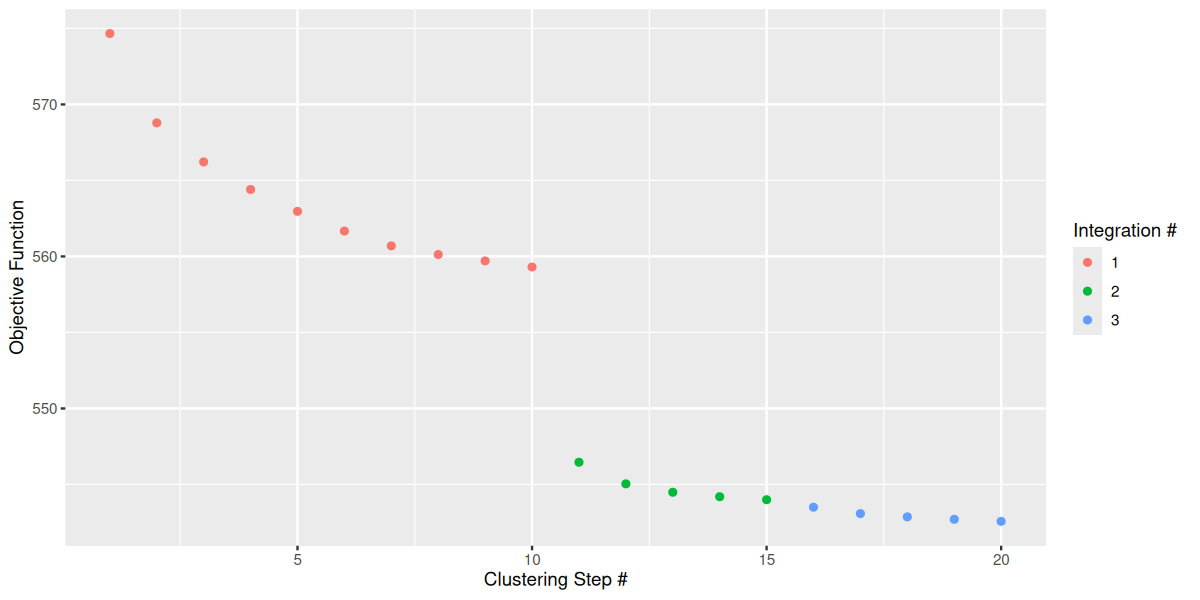

In [52]:
mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")
sub = neuron_sub

assay = sub@assays$RNA$counts
meta = sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

sub1 = CreateSeuratObject(counts = new_assay)
sub1 = AddMetaData(sub1, meta)

sub1 = NormalizeData(sub1, normalization.method = "LogNormalize", scale.factor = 10000)
sub1 = FindVariableFeatures(sub1, selection.method = "vst", nfeatures = 3000)
sub1 = ScaleData(sub1, features = rownames(sub1))

sub1 = sub1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

sub1 = RunHarmony(
    sub1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

sub1 = sub1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

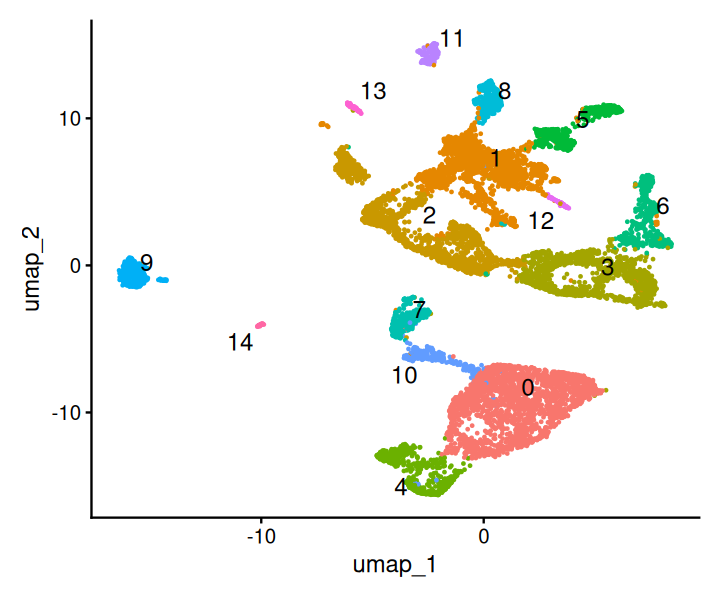

In [55]:
options(repr.plot.width=6, repr.plot.height=5)
DimPlot(object = sub1, reduction = "umap", label = TRUE, label.size = 5, repel = TRUE) + NoLegend()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


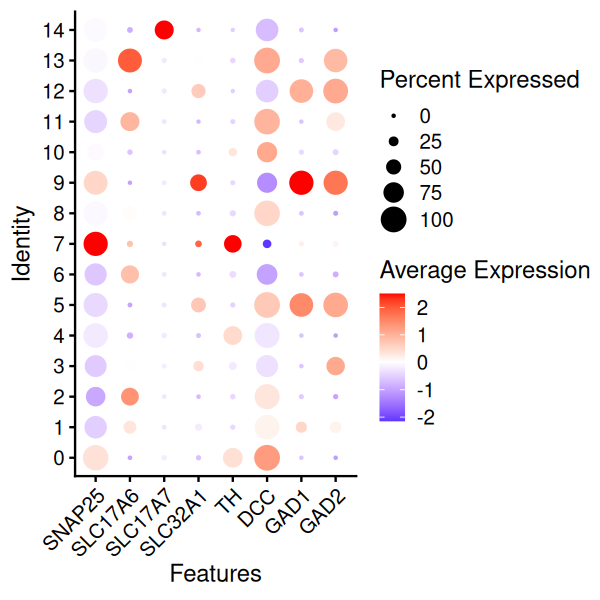

In [62]:
options(repr.plot.width=5, repr.plot.height=5)
DotPlot(sub1, features = c('SNAP25',"SLC17A6", "SLC17A7","SLC32A1", "TH",'DCC', "GAD1", "GAD2")) + 
RotatedAxis() + 
scale_color_gradient2(low = "blue", mid = "white", high = "red") + 
theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

Processing class: Neuron; resolution: 0.3



Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declari

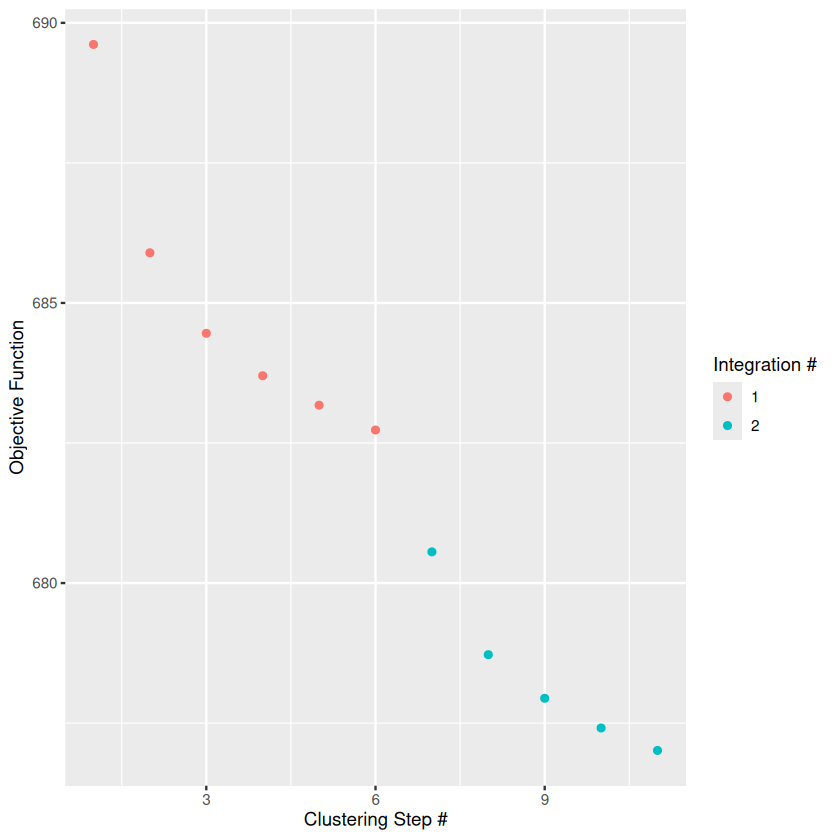

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:00:59 UMAP embedding parameters a = 0.9922 b = 1.112

18:00:59 Read 3771 rows and found 25 numeric columns

18:00:59 Using Annoy for neighbor search, n_neighbors = 30

18:00:59 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18

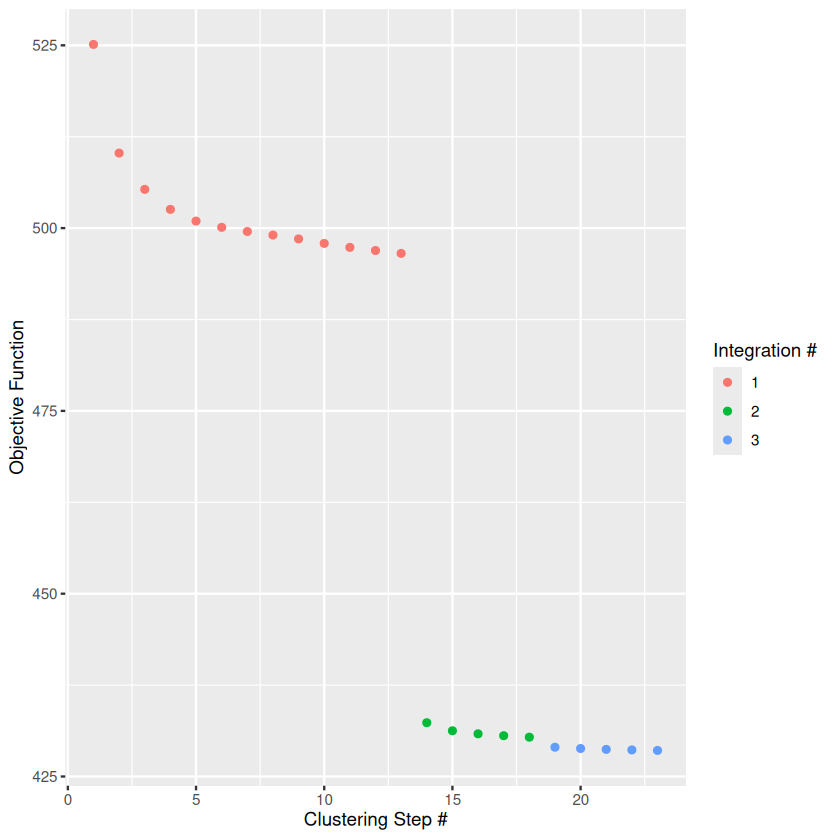

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:03:55 UMAP embedding parameters a = 0.9922 b = 1.112

18:03:55 Read 13640 rows and found 25 numeric columns

18:03:55 Using Annoy for neighbor search, n_neighbors = 30

18:03:55 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

1

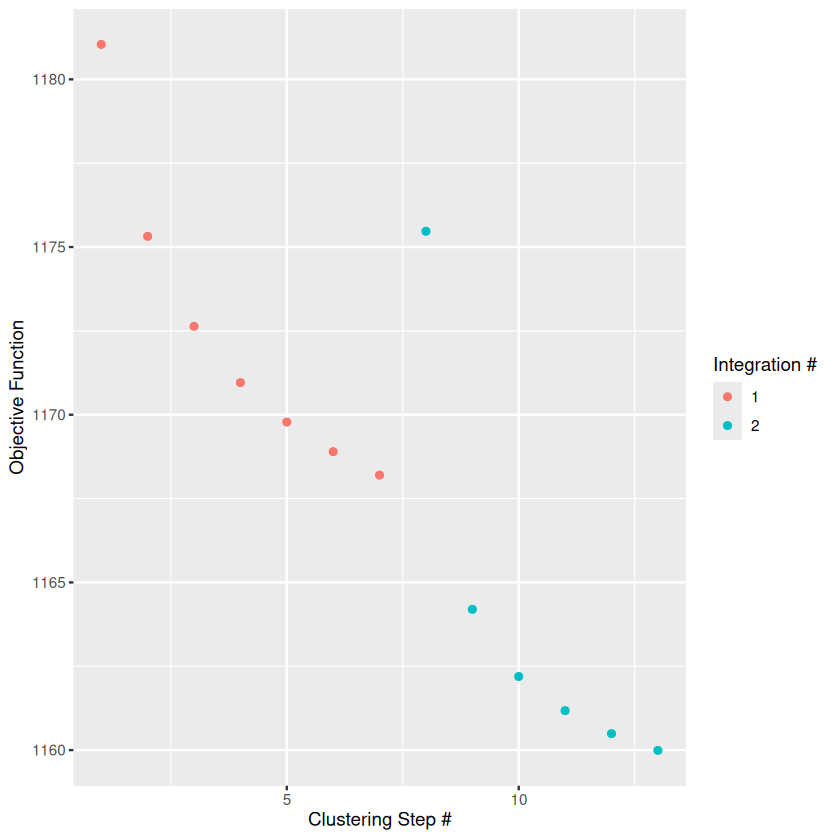

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:10:32 UMAP embedding parameters a = 0.9922 b = 1.112

18:10:32 Read 44235 rows and found 25 numeric columns

18:10:32 Using Annoy for neighbor search, n_neighbors = 30

18:10:32 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

1

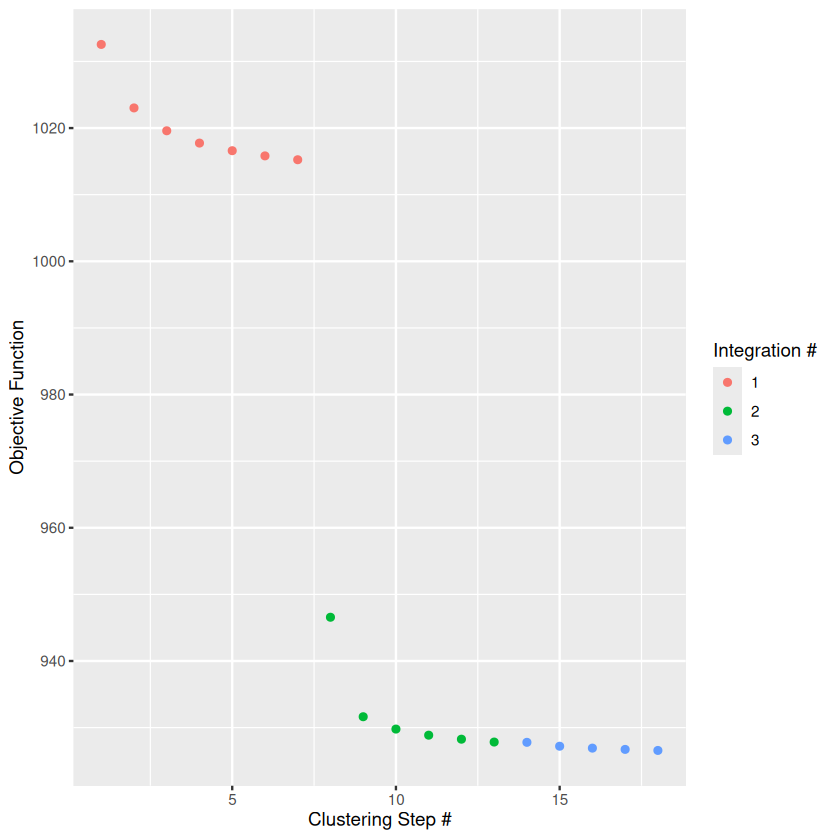

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:13:21 UMAP embedding parameters a = 0.9922 b = 1.112

18:13:21 Read 618 rows and found 25 numeric columns

18:13:21 Using Annoy for neighbor search, n_neighbors = 30

18:13:21 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:

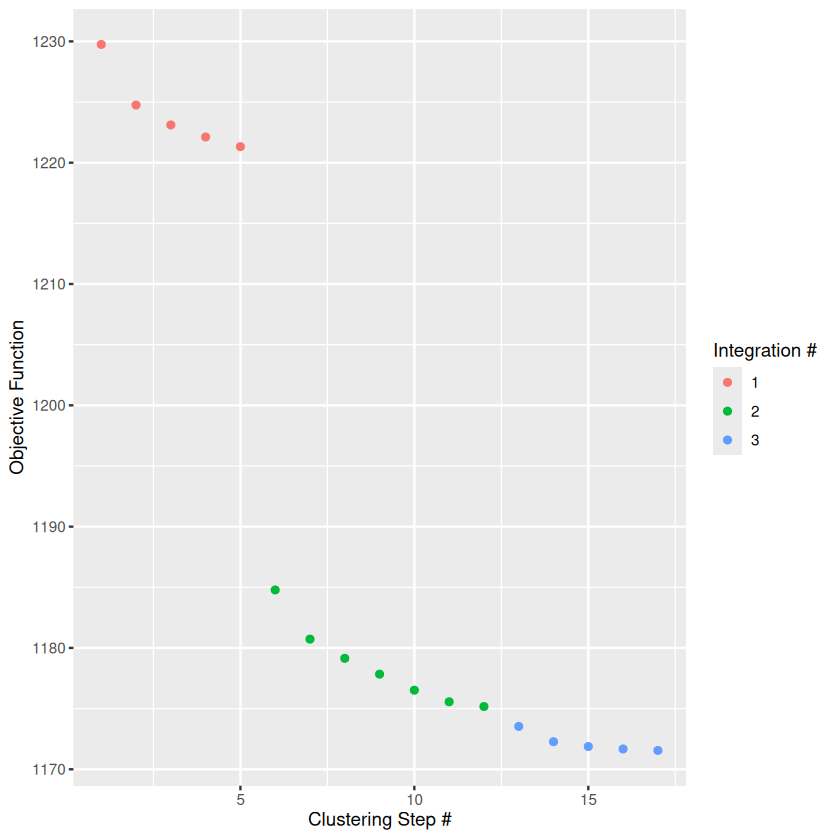

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:16:30 UMAP embedding parameters a = 0.9922 b = 1.112

18:16:30 Read 8225 rows and found 25 numeric columns

18:16:30 Using Annoy for neighbor search, n_neighbors = 30

18:16:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18

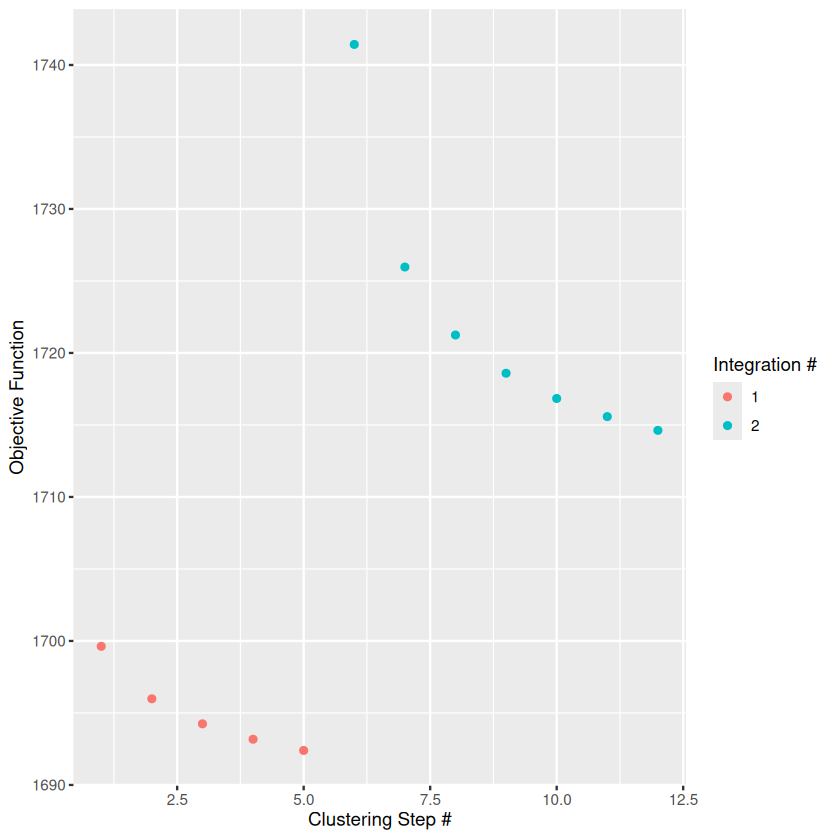

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:19:33 UMAP embedding parameters a = 0.9922 b = 1.112

18:19:33 Read 4942 rows and found 25 numeric columns

18:19:33 Using Annoy for neighbor search, n_neighbors = 30

18:19:33 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18

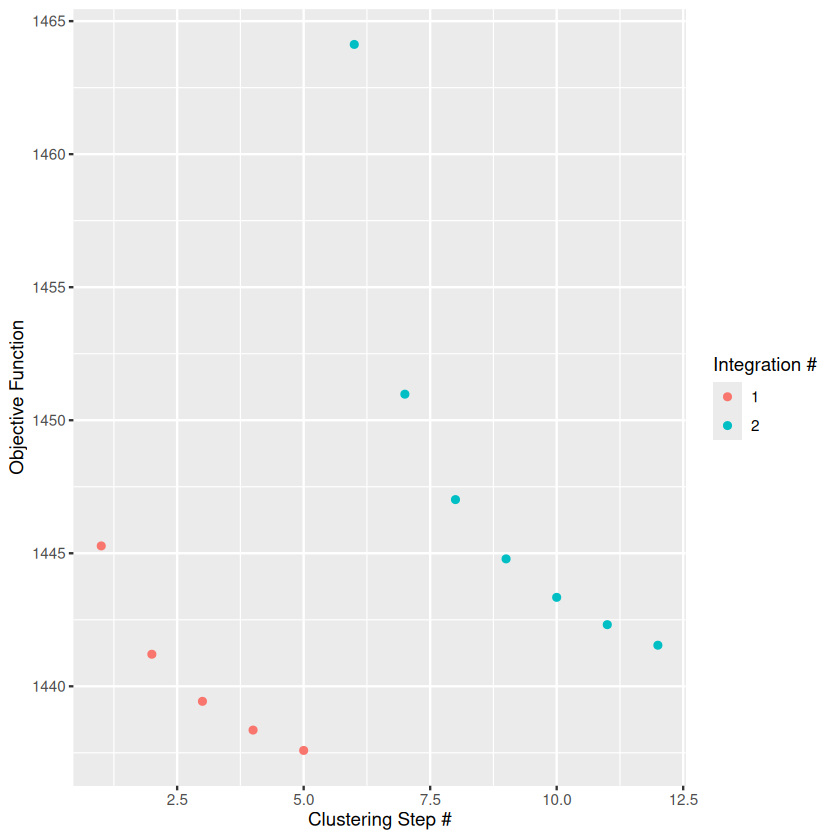

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
18:22:18 UMAP embedding parameters a = 0.9922 b = 1.112

18:22:18 Read 817 rows and found 25 numeric columns

18:22:18 Using Annoy for neighbor search, n_neighbors = 30

18:22:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:

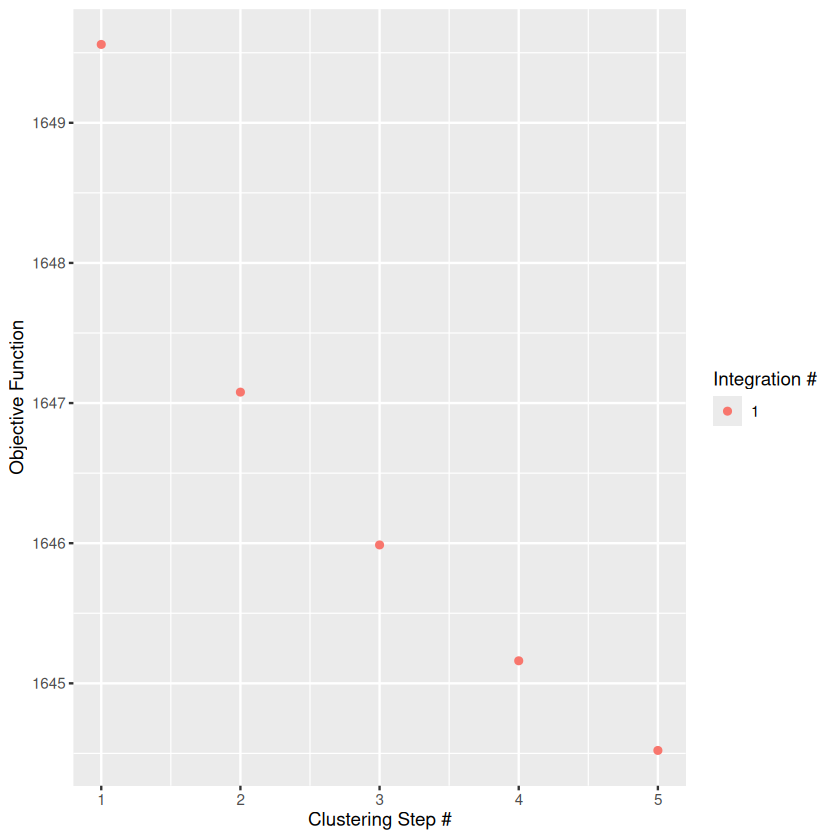

In [ ]:
class_list = c('Neuron', 'DA', 'Astro', 'Oligo', 'Endotheial', 'OPC', 'Micro', 'VLMC')

# 按 class 设置聚类分辨率；可根据各类细胞的聚类结果继续调整
resolution_by_class = c(
    Neuron = 0.3,
    DA = 0.3,
    Astro = 0.3,
    Oligo = 0.4,
    Endotheial = 0.1,
    OPC = 0.2,
    Micro = 0.1,
    VLMC = 0.1
)

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

class_results = list()

for (class_name in class_list) {
    class_resolution = resolution_by_class[[class_name]]
    message("Processing class: ", class_name, "; resolution: ", class_resolution)

    sub = subset(seurat, Class == class_name)

    # 剔除线粒体基因
    assay = sub@assays$RNA$counts
    meta = sub@meta.data
    new_assay = assay[setdiff(rownames(assay), mt_gene), ]

    sub1 = CreateSeuratObject(counts = new_assay)
    sub1 = AddMetaData(sub1, meta)

    sub1 = NormalizeData(sub1, normalization.method = "LogNormalize", scale.factor = 10000)
    sub1 = FindVariableFeatures(sub1, selection.method = "vst", nfeatures = 3000)
    sub1 = ScaleData(sub1, features = rownames(sub1))

    sub1 = sub1 %>%
        RunPCA(npcs = 50, verbose = FALSE) %>%
        FindNeighbors(dims = 1:25) %>%
        FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
        RunUMAP(dims = 1:25, umap.method = "umap-learn")

    sub1 = RunHarmony(
        sub1, group.by.vars = "Animal", plot_convergence = TRUE,
        reduction.save = "harmony", dims.use = 1:25,
        theta = 2
    )

    sub1 = sub1 %>%
        FindNeighbors(reduction = "harmony", dims = 1:25) %>%
        FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
        RunUMAP(reduction = "harmony", dims = 1:25)

    class_results[[class_name]] = sub1
}

# 每个 class 的结果都在 class_results 中，例如：class_results[["Neuron"]]

In [102]:
# 单独重跑指定 class 的聚类；无需重复 PCA 和 Harmony
rerun_class_clustering = function(class_name, new_resolution) {
    if (!class_name %in% names(class_results)) {
        stop("class_results 中不存在 class: ", class_name)
    }
    if (!is.numeric(new_resolution) || length(new_resolution) != 1 || new_resolution <= 0) {
        stop("new_resolution 必须是一个大于 0 的数值")
    }

    message("Reclustering ", class_name, "; resolution: ", new_resolution)

    sub1 = class_results[[class_name]] %>%
        FindNeighbors(reduction = "harmony", dims = 1:25) %>%
        FindClusters(verbose = FALSE, resolution = new_resolution, random.seed = 1234) %>%
        RunUMAP(reduction = "harmony", dims = 1:25, seed.use = 1234)

    class_results[[class_name]] <<- sub1
    resolution_by_class[[class_name]] <<- new_resolution

    invisible(sub1)
}

# 示例：仅以 0.9 的分辨率重跑 Neuron
rerun_class_clustering("Neuron", 0.7)

Reclustering Neuron; resolution: 0.7

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
14:43:55 UMAP embedding parameters a = 0.9922 b = 1.112

14:43:55 Read 7902 rows and found 25 numeric columns

14:43:55 Using Annoy for neighbor search, n_neighbors = 30

14:43:55 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*

In [9]:
class_results$Neuron

An object of class Seurat 
20344 features across 7902 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

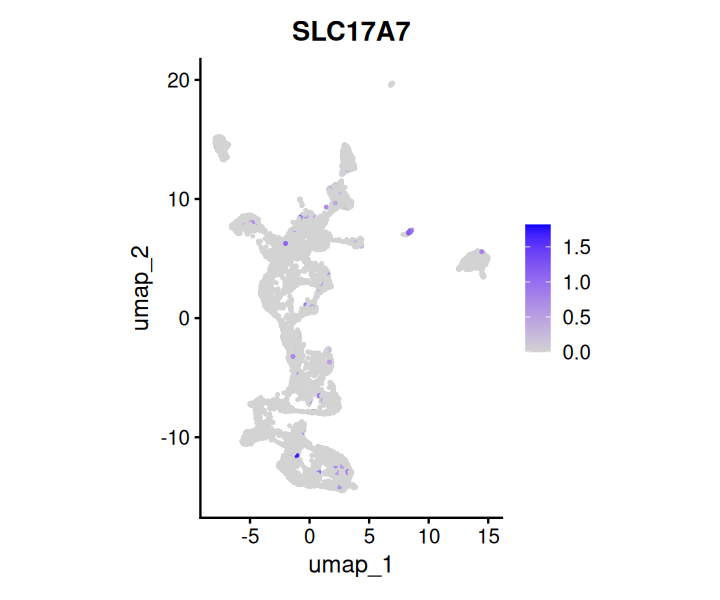

In [40]:
FeaturePlot(class_results$Neuron, features = c("SLC17A7"), raster = FALSE) + coord_fixed()

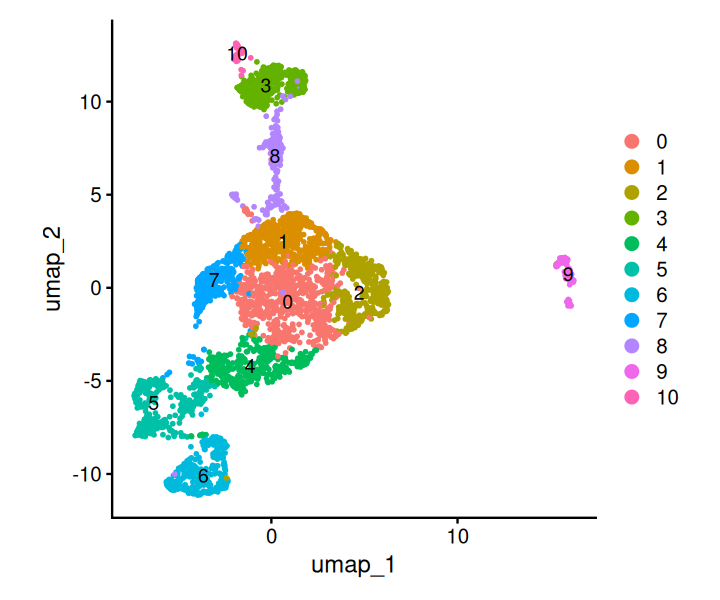

In [36]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(class_results$DA) <- 'seurat_clusters'
DimPlot(class_results$DA, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [15]:
class_results$Neuron@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,Species,Animal,sample_name,Library,main structure,area,path,⋯,nFeature_SCT,SCT_snn_res.0.7,seurat_clusters,SCT_snn_res.0.5,Mouse_anno,class,maxPredClassScore,maxPredClass,Class,RNA_snn_res.0.3
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<int>,<fct>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>
cDNA-250114094:CELL3_N2,SeuratProject,14785,4744,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1426,15,0,5,20 MB GABA,Neuron,0.8800000,Neuron,Neuron,0
cDNA-250114094:CELL11_N1,SeuratProject,8075,3531,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1312,8,6,5,14 HY Glut,Neuron,0.9100000,Neuron,Neuron,6
cDNA-250114094:CELL16_N6,SeuratProject,25882,5682,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1278,8,1,5,19 MB Glut,Neuron,0.9100000,Neuron,Neuron,1
cDNA-250114094:CELL24_N3,SeuratProject,13514,4450,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1369,26,12,21,23 P Glut,Neuron,0.9066667,Neuron,Neuron,12
cDNA-250114094:CELL52_N2,SeuratProject,6955,3349,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1314,8,1,5,14 HY Glut,Neuron,0.8100000,Neuron,Neuron,1
cDNA-250114094:CELL57_N2,SeuratProject,12611,4372,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,⋯,1333,8,0,5,19 MB Glut,Neuron,0.9700000,Neuron,Neuron,0


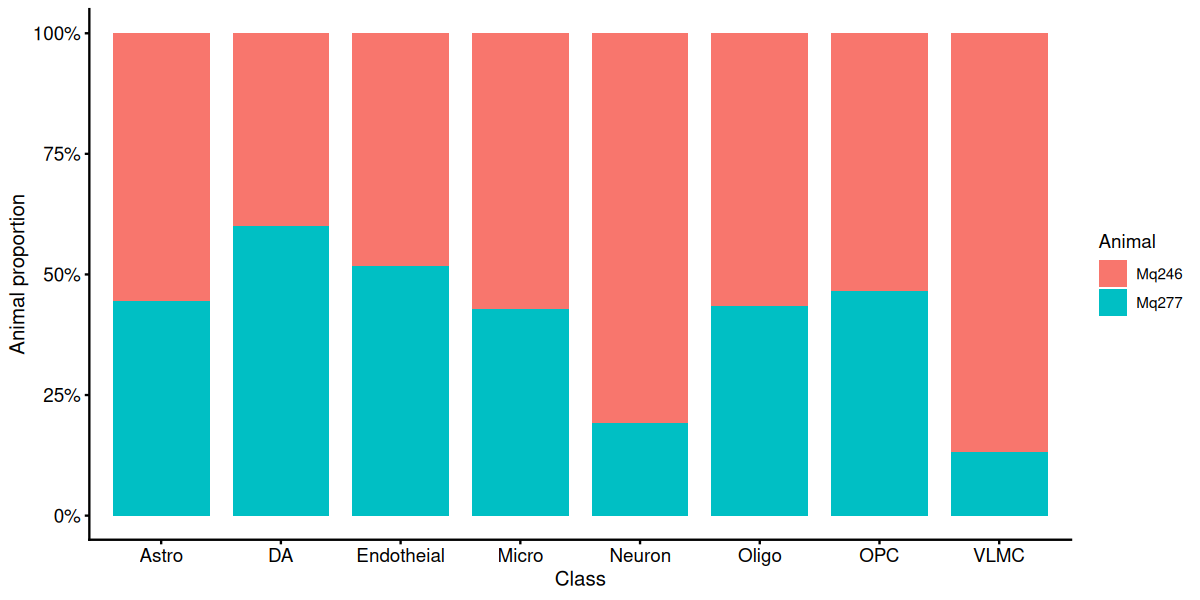

In [ ]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- seurat@meta.data %>%
    as.data.frame() %>%
    dplyr::count(Class, Animal) %>%
    dplyr::group_by(Class) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(Class), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "Class", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [47]:
cluster_animal_df

class_new,Animal,n,proportion
<chr>,<fct>,<int>,<dbl>
Astro,Mq246,7575,0.5553519
Astro,Mq277,6065,0.4446481
Endotheial,Mq246,299,0.4838188
Endotheial,Mq277,319,0.5161812
Micro,Mq246,2830,0.5726427
Micro,Mq277,2112,0.4273573
OPC,Mq246,4395,0.5343465
OPC,Mq277,3830,0.4656535
Oligo,Mq246,25028,0.5657963


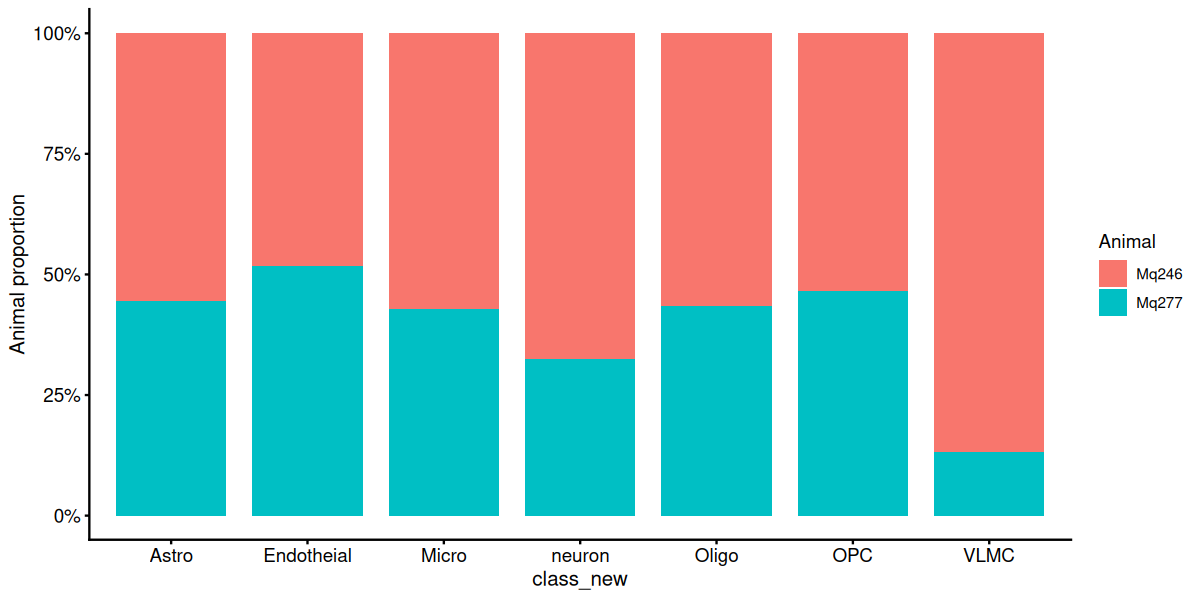

In [46]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- seurat@meta.data %>%
    as.data.frame() %>%
    dplyr::count(class_new, Animal) %>%
    dplyr::group_by(class_new) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(class_new), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "class_new", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [68]:
table(class_results$Neuron@meta.data$seurat_clusters)


   0    1    2    3    4    5    6    7    8    9   10   11 
1980 1628 1469  623  603  408  408  377  220  108   46   32 

In [92]:
sub_filter = class_results$Neuron

sub_filter = subset(x = sub_filter, subset = !(seurat_clusters %in% c("1", "4", "5", "6", "10", "11")))
sub_filter

An object of class Seurat 
20344 features across 4777 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

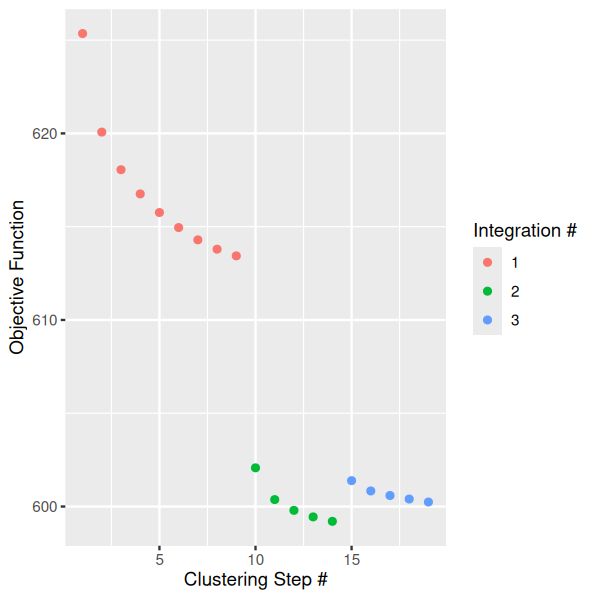

In [97]:
mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")
# sub = sub_filter
sub = sub1

assay = sub@assays$RNA$counts
meta = sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

sub1 = CreateSeuratObject(counts = new_assay)
sub1 = AddMetaData(sub1, meta)

sub1 = NormalizeData(sub1, normalization.method = "LogNormalize", scale.factor = 10000)
sub1 = FindVariableFeatures(sub1, selection.method = "vst", nfeatures = 3000)
sub1 = ScaleData(sub1, features = rownames(sub1))

sub1 = sub1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

sub1 = RunHarmony(
    sub1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

sub1 = sub1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = 0.2, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

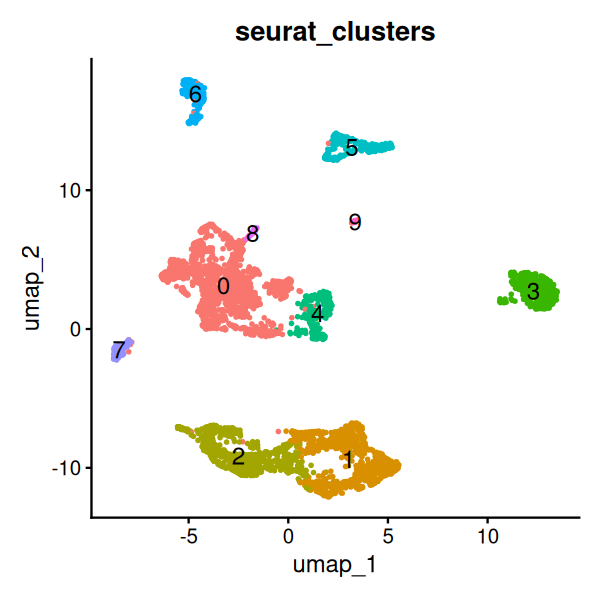

In [98]:
options(repr.plot.width=5, repr.plot.height=5)
DimPlot(sub1, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5) + NoLegend()

In [100]:
sub1 = subset(sub1, !(seurat_clusters %in% c("4","9")))

In [104]:
table(class_results$Neuron$seurat_clusters)


  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19 
863 665 546 421 409 408 405 401 401 354 353 348 332 302 275 275 275 222 220 164 
 20  21  22  23  24  25 
108  46  35  32  24  18 

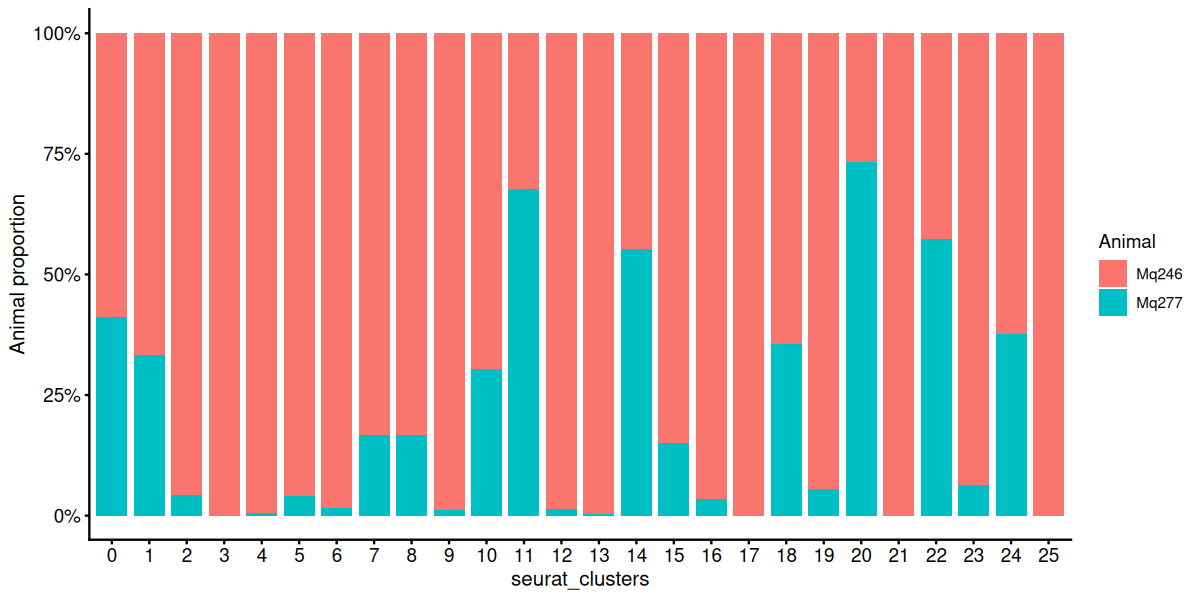

In [103]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- class_results$Neuron@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

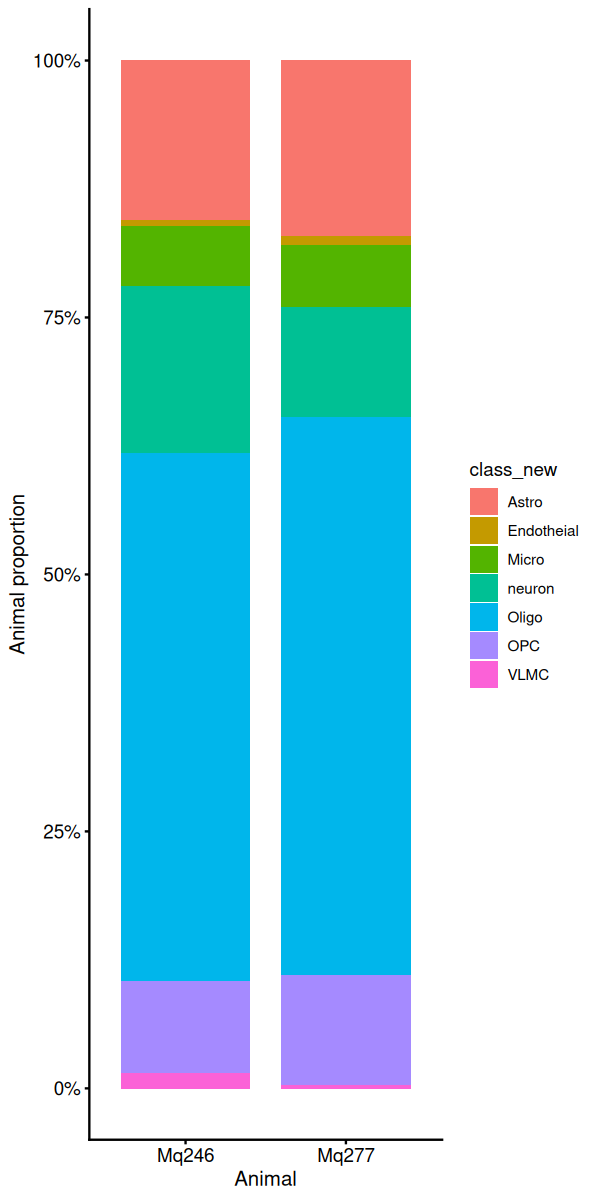

In [ ]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- seurat@meta.data %>%
    as.data.frame() %>%
    dplyr::count(class_new, Animal) %>%
    dplyr::group_by(Animal) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=5, repr.plot.height=10)
ggplot(cluster_animal_df, aes(x = factor(Animal), y = proportion, fill = class_new)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "Animal", y = "Animal proportion", fill = "class_new") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [34]:
table(class_results$DA$Animal, class_results$DA$seurat_clusters)

       
          0   1   2   3   4   5   6   7   8   9  10
  Mq246 274 284 222  60 147 135  67 173  42 103   2
  Mq277 402 218 228 345 249 212 270 112 189   0  37

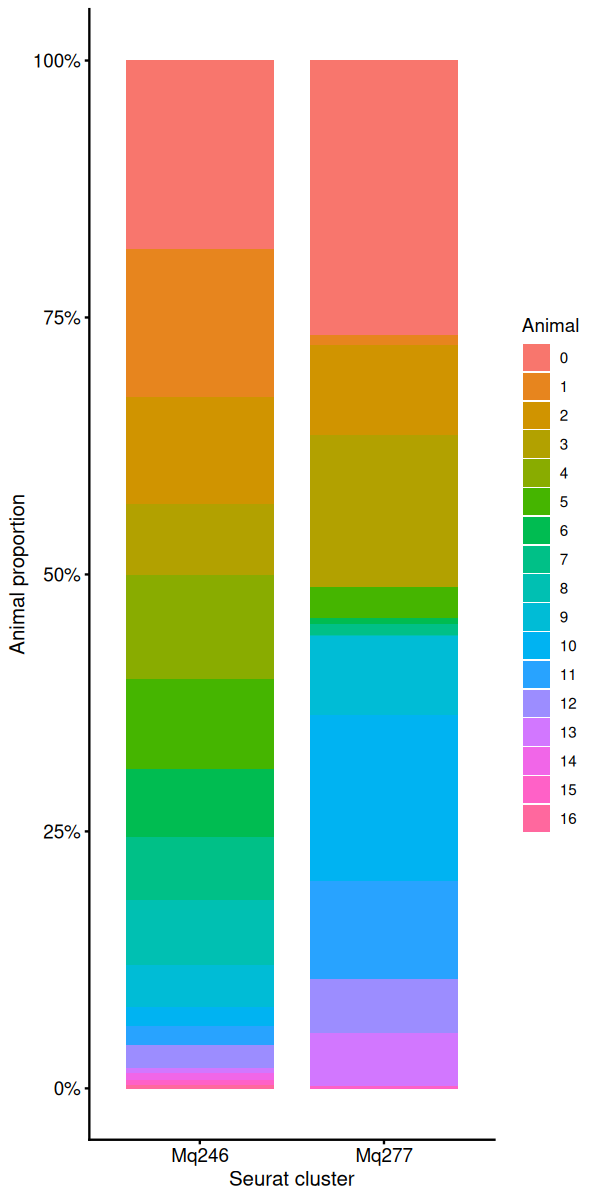

In [23]:
table(class_results$DA$seurat_clusters)


Mq246 Mq277 
 1509  2262 

In [37]:
Idents(class_results$DA) <- 'seurat_clusters'
markers = FindAllMarkers(class_results$DA, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")
markers

Calculating cluster 0




Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 1


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 2


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 3


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 4


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 5


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likeli

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
EBF1,2.061836e-220,1.7026968,0.984,0.607,4.194599e-216,0,EBF1
LRRTM4,9.703465e-171,1.2661864,0.999,0.795,1.974073e-166,0,LRRTM4
RGS7,8.067077e-168,0.9677328,1.000,0.845,1.641166e-163,0,RGS7
MAML3,1.156912e-156,1.2874969,0.984,0.713,2.353622e-152,0,MAML3
GALNTL6,1.583940e-156,1.1089455,1.000,0.832,3.222368e-152,0,GALNTL6
PRICKLE2,1.407225e-152,0.9335873,0.997,0.812,2.862859e-148,0,PRICKLE2
ERBB4,1.870620e-145,1.0508060,1.000,0.766,3.805590e-141,0,ERBB4
OSBPL3,6.353107e-145,1.6933536,0.805,0.284,1.292476e-140,0,OSBPL3
UNC5D,2.029207e-144,1.3041659,0.979,0.666,4.128218e-140,0,UNC5D


In [38]:
table(markers$cluster)


   0    1    2    3    4    5    6    7    8    9   10 
1464 3096 1866 5117 1768 3959 3193 3108 4425 2181 4131 

In [39]:
# colnames(da_res_2)[colnames(da_res_2) == "gene"] <- "peak"

markers_filt = markers
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))


markers_filt = subset(markers_filt, p_val_adj < 0.05)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


   0    1    2    3    4    5    6    7    8    9   10 
 304  828  377 3861  456  951 1149  687 2042  793 2519 

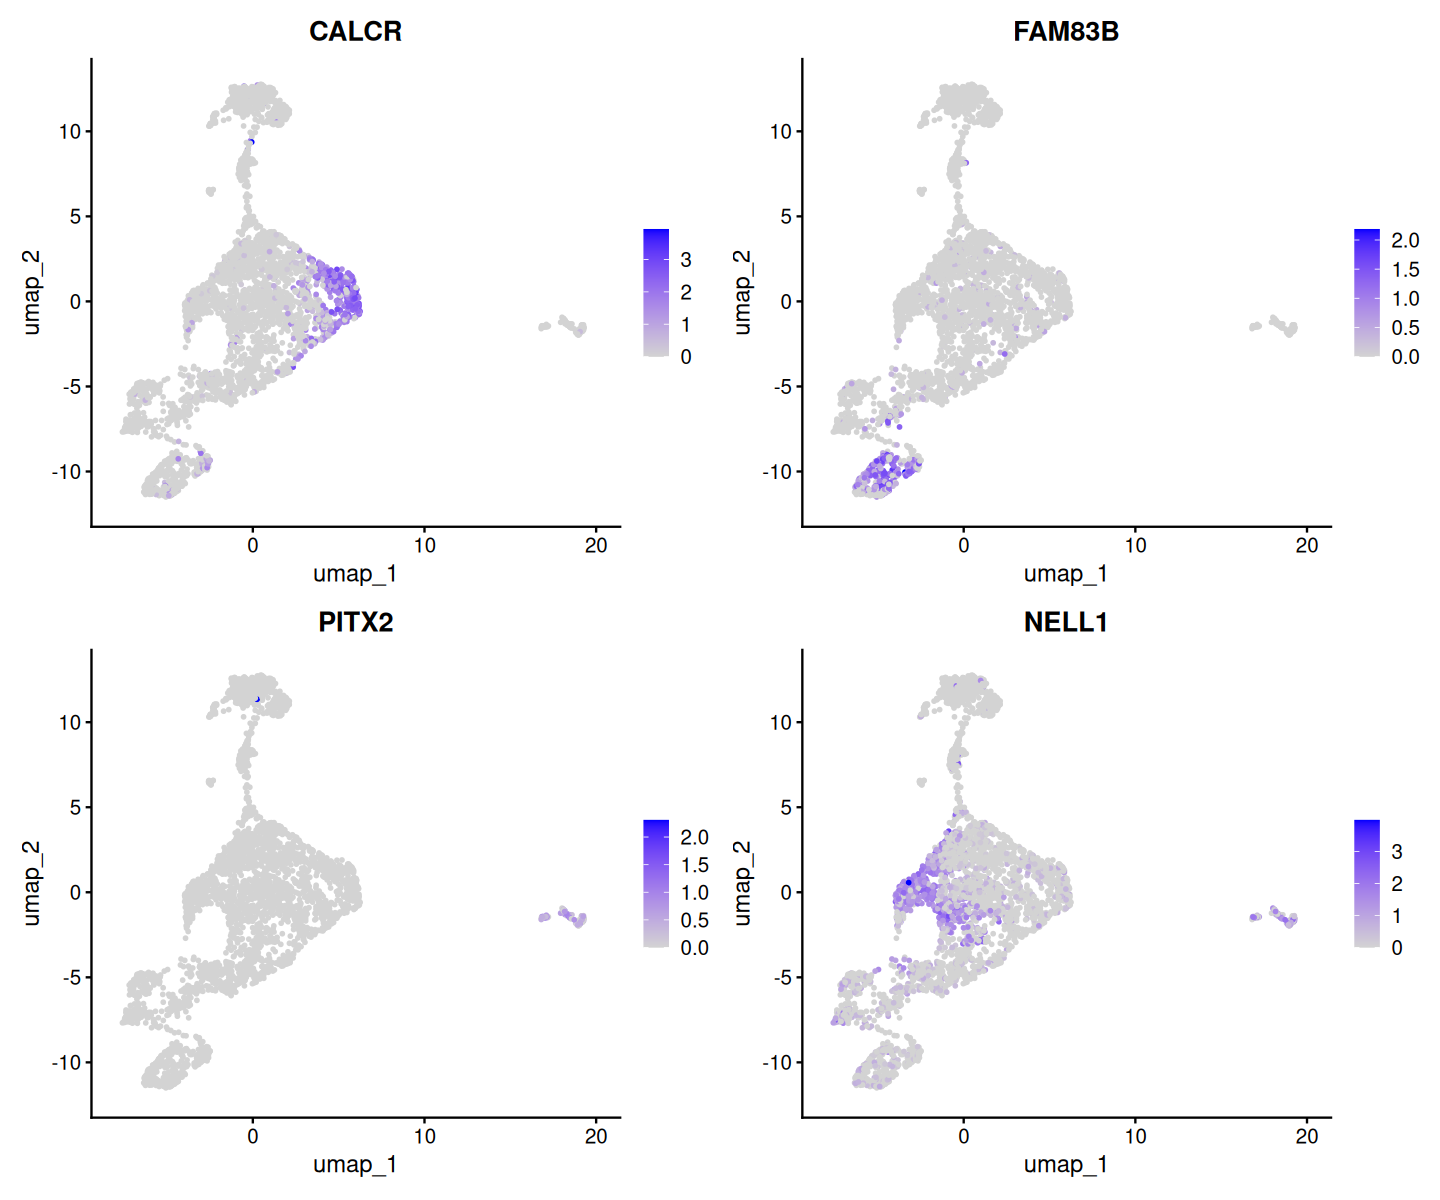

In [77]:
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(class_results$DA, features = c("CALCR","FAM83B","PITX2","NELL1"), ncol = 2, raster = FALSE)
# FeaturePlot(class_results$DA, features = c("PITX2","NELL1"), ncol = 2, raster = FALSE)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


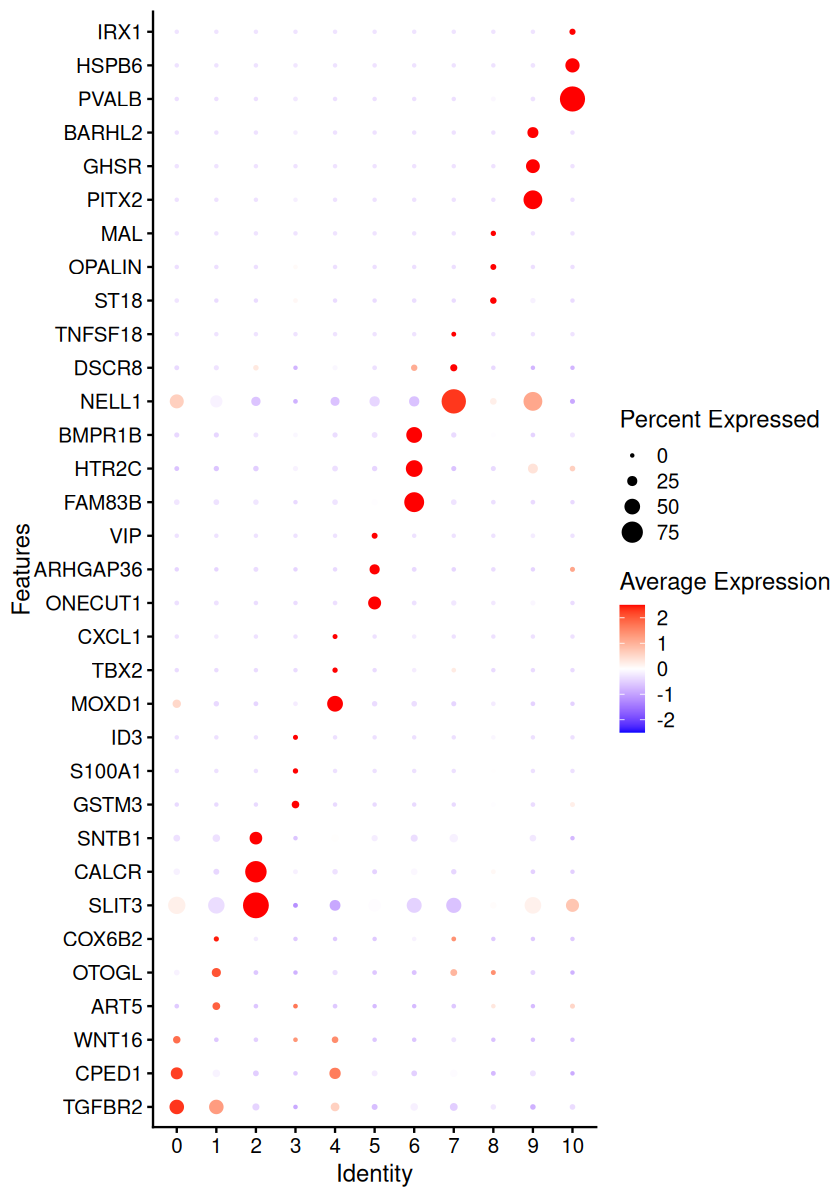

In [58]:
markers_filt_top10 = markers_filt %>% group_by(cluster) %>% top_n(n = 3, wt = avg_log2FC)
options(repr.plot.width=7, repr.plot.height=10)
DotPlot(class_results$DA, features = unique(markers_filt_top10$gene), dot.scale = 6) +
    coord_flip() +
    theme(axis.text.y = element_text(size = 12),axis.text.x = element_text(size = 12)) +
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, limits = c(-2.5, 2.5))

In [ ]:
markers_filt_top50 = markers_filt %>% group_by(cluster) #%>% top_n(n = 100, wt = avg_log2FC)

gene_list_olg_up <- split(markers_filt_top50$gene,markers_filt_top50$cluster)
gene_list_olg_up

$`0`
  [1] "EBF1"       "LRRTM4"     "RGS7"       "MAML3"      "GALNTL6"   
  [6] "PRICKLE2"   "ERBB4"      "OSBPL3"     "UNC5D"      "ASTN2"     
 [11] "KIRREL3"    "BNC2"       "PRKCA"      "LMO3"       "CDH13"     
 [16] "MCTP1"      "PTPN13"     "PXDN"       "EFNA5"      "GPR149"    
 [21] "COL25A1"    "LIFR"       "ST6GALNAC5" "RGSL1"      "RASGEF1B"  
 [26] "RFTN1"      "WDFY2"      "HTR7"       "ANGPT1"     "SLC25A13"  
 [31] "LAMA3"      "TLL1"       "SLIT2"      "ZNF385B"    "THTPA"     
 [36] "GNA14"      "NPNT"       "PDGFC"      "PDE1C"      "PMFBP1"    
 [41] "MYOM1"      "TGFBR2"     "PRLR"       "TPD52L1"    "PLEKHG1"   
 [46] "ZNF608"     "SEMA5B"     "FAM107B"    "ARHGEF26"   "FIGN"      
 [51] "CPED1"      "NUP160"     "MYO1B"      "SLC4A4"     "NOX4"      
 [56] "PRSS55"     "LGR6"       "COL6A6"     "DIAPH3"     "CNBD1"     
 [61] "GRM3"       "ALK"        "WNT16"      "HRH2"       "ATP8B1"    
 [66] "PIEZO2"     "SALL4"      "MGAT4C"     "NPFFR2"     "LRRC55"    
 [71] "CDYL"       "ASB4"       "SLC17A8"    "COL21A1"    "EPSTI1"    
 [76] "NR4A3"      "INS"        "RASSF6"     "NR4A1"      "NPY1R"     
 [81] "ADAMTS16"   "NPAS4"      "SLC15A5"    "FST"        "RREB1"     
 [86] "IGF2BP3"    "SMAD3"      "MSTN"       "SLC5A8"     "SYCP1"     
 [91] "CDCP1"      "KCNH6"      "OCLN"       "CPS1"       "MPO"       
 [96] "COL22A1"    "ADM"        "WDR72"      "C9orf135"   "C3H7orf57" 

$`1`
  [1] "SOX6"       "ITPR1"      "CUX2"       "CRISPLD1"   "PTPN13"    
  [6] "CADPS"      "PEX5L"      "ABHD2"      "NKAIN3"     "OLFM3"     
 [11] "CCDC112"    "RORB"       "COL11A1"    "LMO3"       "RERG"      
 [16] "OSBPL3"     "MAN1C1"     "BVES"       "SVEP1"      "IFT57"     
 [21] "VWC2"       "SLC19A2"    "NOS1AP"     "MPP6"       "LPO"       
 [26] "LIN7A"      "KLHL5"      "SEMA3E"     "ST3GAL1"    "PLEKHH2"   
 [31] "CACNA1G"    "LRRC66"     "CDH12"      "ST8SIA2"    "ABCA1"     
 [36] "CYBRD1"     "GABRA4"     "CNBD1"      "NOX4"       "LGR6"      
 [41] "PGGT1B"     "BDH1"       "GSDME"      "BCL2L11"    "PTPN14"    
 [46] "PIK3R5"     "NID1"       "BEND4"      "KITLG"      "CSGALNACT1"
 [51] "QRFPR"      "ART5"       "PYGL"       "FAM20A"     "OTOGL"     
 [56] "RELL1"      "MCTP2"      "KCNQ4"      "BCL11B"     "CR1L"      
 [61] "ADAMTS20"   "SRPX"       "TSPAN16"    "EGFLAM"     "ADAMTSL1"  
 [66] "SERPINE3"   "GTF2A1L"    "FER1L6"     "TRPC7"      "ZSCAN10"   
 [71] "OMD"        "LIX1"       "COL4A6"     "PLSCR5"     "TMEM253"   
 [76] "SYCP1"      "SEPT14"     "MATN1"      "DIRC3"      "C14orf178" 
 [81] "CYP2C75"    "SH2D4A"     "ZSCAN5A"    "ZNF530"     "GAS2L3"    
 [86] "COX6B2"     "E2F2"       "SDS"        "KLK4"       "UMOD"      
 [91] "FAM155B"    "ACSS3"      "KLHL34"     "AMPD1"      "CCDC195"   
 [96] "GAL3ST3"    "C1orf127"   "CLPSL1"     "FEZF2"      "EPCAM"     

$`2`
  [1] "SLIT3"    "CALCR"    "PLCB4"    "SLC35D2"  "CACNA2D3" "PBX3"    
  [7] "RUNX1T1"  "PTPRG"    "ZBTB7C"   "CDH20"    "RBFOX1"   "CDH4"    
 [13] "ABTB2"    "PDZRN3"   "COBL"     "DOK5"     "ROBO1"    "ARPP21"  
 [19] "IL1RAPL2" "TOX"      "CDH6"     "ASIC2"    "FNDC3B"   "EBF3"    
 [25] "BDNF"     "NPNT"     "RERG"     "EEPD1"    "PLXNC1"   "SNTG2"   
 [31] "PLA2R1"   "ZMAT4"    "KCTD8"    "NTNG1"    "ZDHHC2"   "PDE8B"   
 [37] "SNTB1"    "CEP112"   "ITPR2"    "CACHD1"   "LAMA3"    "FGF20"   
 [43] "IGF1"     "SLC17A8"  "MOCOS"    "CCKAR"    "LEMD1"    "TRPC6"   
 [49] "LMX1A"    "PTCHD1"   "LMO4"     "HABP4"    "CPNE8"    "SGCZ"    
 [55] "BCL2"     "TRPC3"    "COL4A5"   "CHRNA5"   "BEND7"    "ARHGAP28"
 [61] "KITLG"    "STC1"     "ADRA1B"   "STK32B"   "CCDC192"  "DOCK5"   
 [67] "SLC24A4"  "ADAM28"   "PDE9A"    "LRTM1"    "COL14A1"  "RXRA"    
 [73] "EBF2"     "THSD4"    "KCNK9"    "LEF1"     "NABP1"    "SLC15A2" 
 [79] "RAVER2"   "OTOF"     "EAF2"     "SYNPR"    "CHRNA3"   "ARAP3"   
 [85] "ENTHD1"   "EPHA3"    "CHST9"    "CD302"    "PRKD1"    "NPFFR2"  
 [91] "RCVRN"    "ZNF367"   "CLDN10"   "CFTR"     "PGM5"     "S

In [65]:
library(enrichR)
gene_list_olg_up = gene_list_olg_up[sapply(gene_list_olg_up, length) > 0]
lapply(names(gene_list_olg_up), function(x){
  enrichr(gene_list_olg_up[[x]], c("GO_Biological_Process_2025"))$GO_Biological_Process_2025 %>%
    mutate(seurat_clusters = x)
}) %>% bind_rows() -> GO_df_up1

Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  

In [68]:
GO_df_up1

Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes,seurat_clusters
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
Regulation of Phosphatidylinositol 3-Kinase/Protein Kinase B Signal Transduction (GO:0051896),8/219,1.426279e-05,0.008164762,0,0,8.114156,90.53659,MSTN;ANGPT1;PDGFC;PRKCA;EFNA5;WNT16;PTPN13;INS,0
Cell Surface Receptor Protein Tyrosine Kinase Signaling Pathway (GO:0007169),9/296,1.767264e-05,0.008164762,0,0,6.758701,73.96380,ALK;NR4A3;ANGPT1;ERBB4;PDGFC;PXDN;EFNA5;PRLR;INS,0
Positive Regulation of Epithelial Cell Proliferation (GO:0050679),6/118,2.816378e-05,0.008674445,0,0,11.277356,118.15820,NR4A1;NR4A3;ERBB4;CDH13;PRKCA;RREB1,0
Positive Regulation of Fat Cell Differentiation (GO:0045600),4/50,1.135672e-04,0.022572222,0,0,17.983696,163.34799,LMO3;WDFY2;RREB1;INS,0
+ Reg of Phosphatidylinositol 3-Kinase/Prot Kinase B Signal Transduction (GO:0051897),6/162,1.637648e-04,0.022572222,0,0,8.078560,70.42144,ANGPT1;PDGFC;PRKCA;EFNA5;WNT16;INS,0
Sprouting Angiogenesis (GO:0002040),4/58,2.029154e-04,0.022572222,0,0,15.313272,130.20448,NR4A1;ANGPT1;CDH13;SLIT2,0
Positive Regulation of Multicellular Organismal Process (GO:0051240),9/407,2.036725e-04,0.022572222,0,0,4.846154,41.18745,SMAD3;ANGPT1;FST;PDGFC;PRKCA;PRLR;RREB1;TGFBR2;INS,0
External Encapsulating Structure Organization (GO:0045229),5/111,2.381288e-04,0.022572222,0,0,9.828203,81.99373,ADAMTS16;COL22A1;PXDN;COL6A6;NPNT,0
Extracellular Structure Organization (GO:0043062),5/111,2.381288e-04,0.022572222,0,0,9.828203,81.99373,ADAMTS16;COL22A1;PXDN;COL6A6;NPNT,0


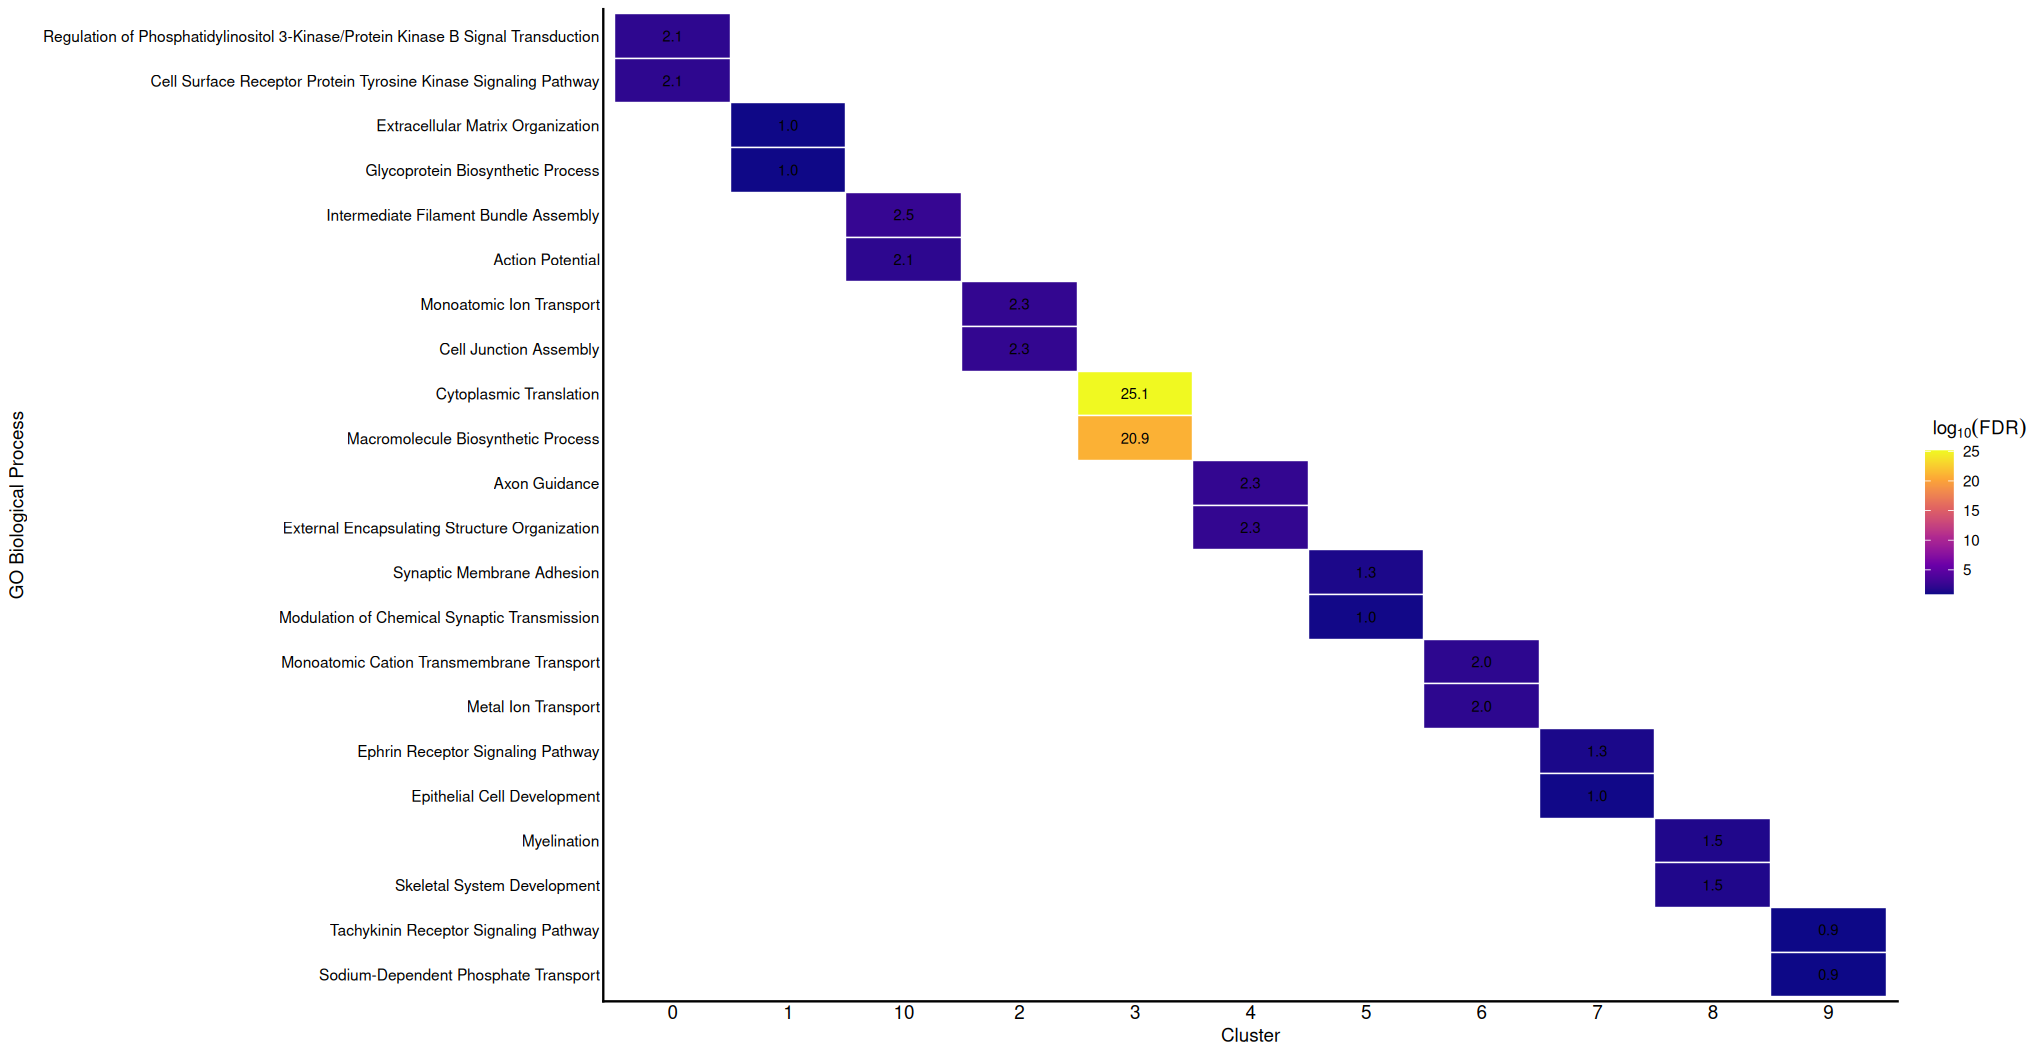

In [66]:
# 每个 cluster 取 FDR 最小的前 2 个 GO term，并绘制富集热图
GO_top2 = GO_df_up1 %>%
    filter(!is.na(Adjusted.P.value), Adjusted.P.value > 0) %>%
    group_by(seurat_clusters) %>%
    slice_min(order_by = Adjusted.P.value, n = 2, with_ties = FALSE) %>%
    ungroup() %>%
    mutate(
        enrichment_score = -log10(Adjusted.P.value),
        Term = sub(" \\(GO:.*\\)$", "", Term),
        Term = factor(Term, levels = rev(unique(Term)))
    )

GO_heatmap = ggplot(GO_top2, aes(x = factor(seurat_clusters), y = Term, fill = enrichment_score)) +
    geom_tile(color = "white", linewidth = 0.3) +
    geom_text(aes(label = sprintf("%.1f", enrichment_score)), size = 3) +
    scale_fill_viridis_c(name = expression(-log[10](FDR)), option = "C") +
    labs(x = "Cluster", y = "GO Biological Process") +
    theme_classic() +
    theme(
        axis.text.x = element_text(size = 11),
        axis.text.y = element_text(size = 9),
        axis.ticks = element_blank()
    )

options(repr.plot.width = 17, repr.plot.height = max(5, 0.4 * nrow(GO_top2)))
print(GO_heatmap)

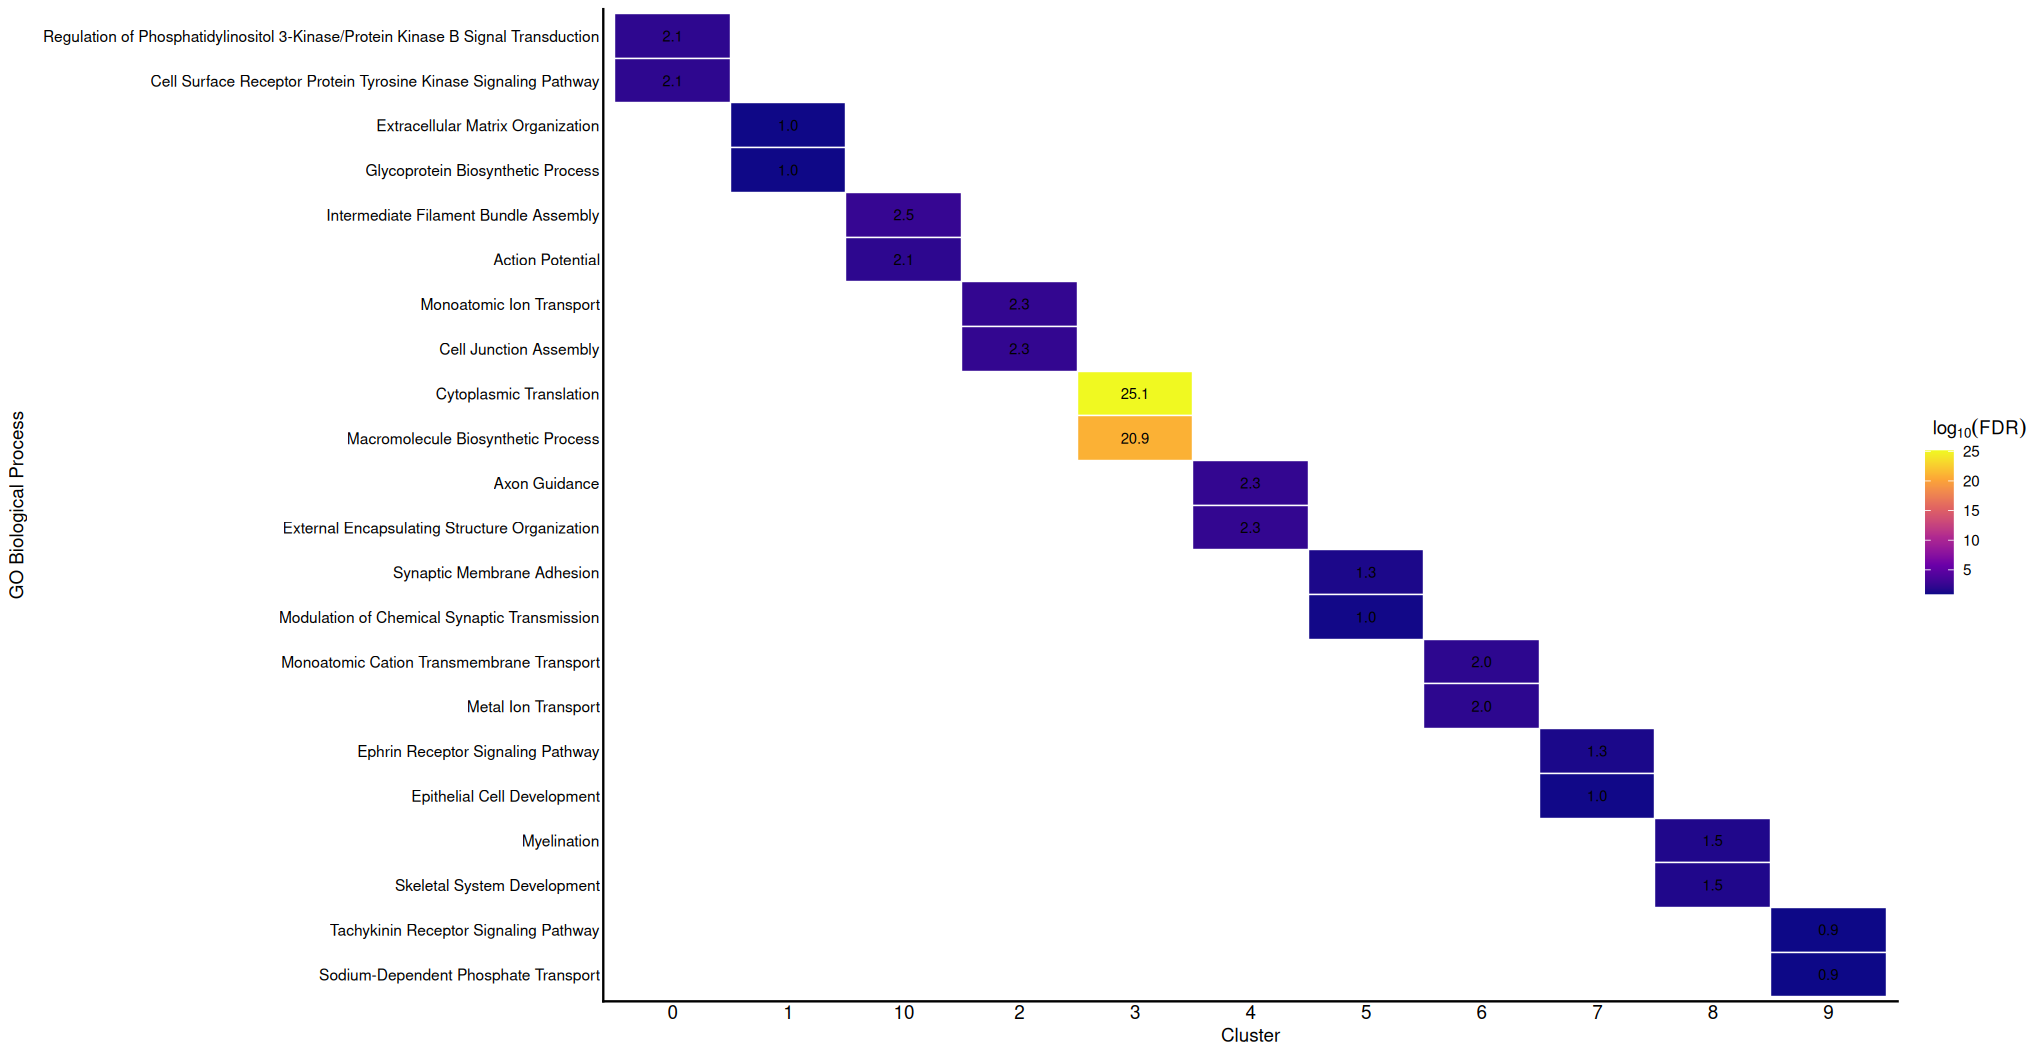

In [67]:
GO_heatmap

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


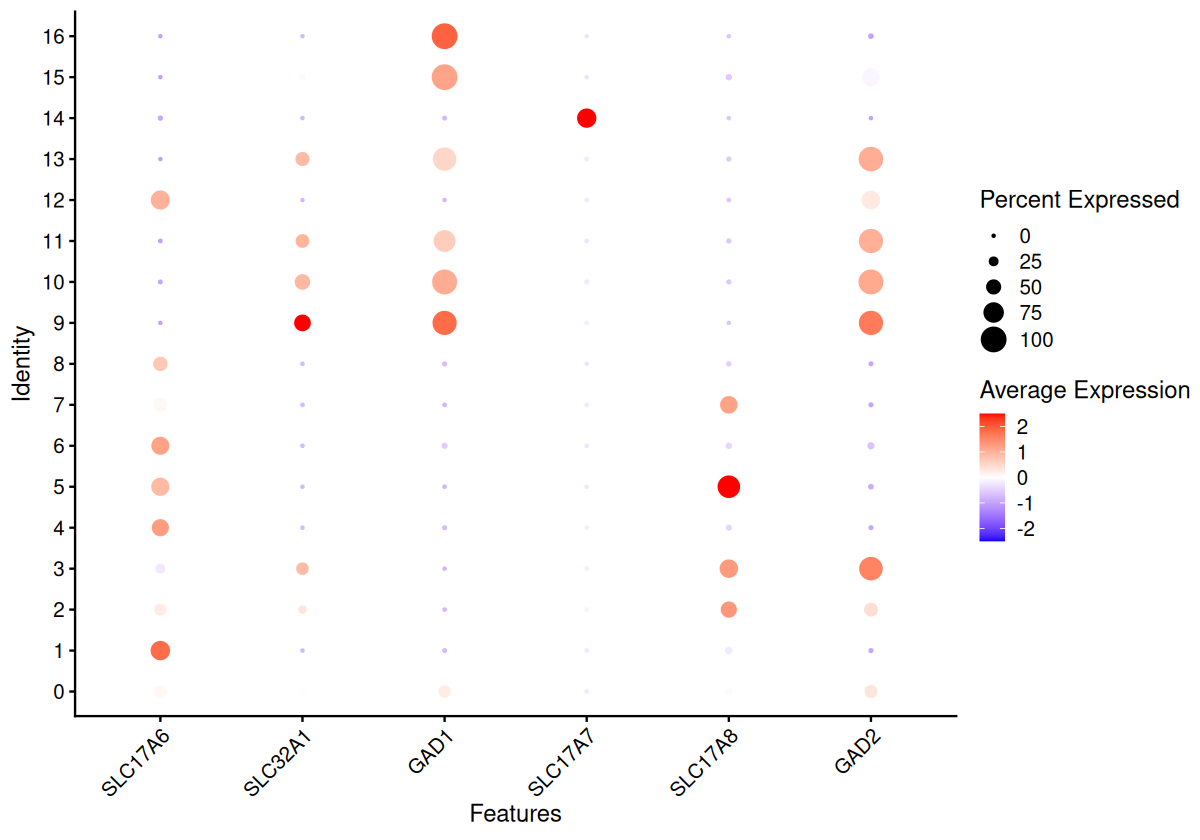

In [29]:
# options(repr.plot.width=10, repr.plot.height=7)
# Idents(seurat_1) <- 'seurat_clusters'
# DimPlot(class_results$Neuron, reduction="umap", label=T,raster=FALSE)+coord_fixed()


options(repr.plot.width=10, repr.plot.height=7)
feature = c('SLC17A6','SLC32A1','GAD1','SLC17A7','SLC17A8','GAD2')
DotPlot(class_results$Neuron, features = feature, cluster.idents = FALSE) +
  RotatedAxis(45) +
  scale_color_gradient2(low ="blue", mid = 'white', high = "red", midpoint = 0, limits = c(-2.5, 2.5))

In [8]:
class_results

$Neuron
An object of class Seurat 
20344 features across 7902 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

$DA
An object of class Seurat 
20344 features across 3771 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

$Astro
An object of class Seurat 
20344 features across 13640 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

$Oligo
An object of class Seurat 
20344 features across 44235 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

$Endotheial
An o

In [9]:
#subclass重命名
class_results$Neuron@meta.data$Subclass=paste0(class_results$Neuron@meta.data$Class,'_',class_results$Neuron@meta.data$seurat_clusters)
class_results$DA@meta.data$Subclass=paste0(class_results$DA@meta.data$Class,'_',class_results$DA@meta.data$seurat_clusters)
class_results$Astro@meta.data$Subclass=paste0(class_results$Astro@meta.data$Class,'_',class_results$Astro@meta.data$seurat_clusters)
class_results$Oligo@meta.data$Subclass=paste0(class_results$Oligo@meta.data$Class,'_',class_results$Oligo@meta.data$seurat_clusters)
class_results$Micro@meta.data$Subclass=paste0(class_results$Micro@meta.data$Class,'_',class_results$Micro@meta.data$seurat_clusters)
class_results$OPC@meta.data$Subclass=paste0(class_results$OPC@meta.data$Class,'_',class_results$OPC@meta.data$seurat_clusters)
class_results$VLMC@meta.data$Subclass=paste0(class_results$VLMC@meta.data$Class,'_',class_results$VLMC@meta.data$seurat_clusters)
class_results$Endotheial@meta.data$Subclass=paste0(class_results$Endotheial@meta.data$Class,'_',class_results$Endotheial@meta.data$seurat_clusters)

In [10]:
sub1=class_results$Neuron@meta.data[,'Subclass',drop=F]
sub2=class_results$DA@meta.data[,'Subclass',drop=F]
sub3=class_results$Astro@meta.data[,'Subclass',drop=F]
sub4=class_results$Oligo@meta.data[,'Subclass',drop=F]
sub5=class_results$Micro@meta.data[,'Subclass',drop=F]
sub6=class_results$OPC@meta.data[,'Subclass',drop=F]
sub7=class_results$VLMC@meta.data[,'Subclass',drop=F]
sub8=class_results$Endotheial@meta.data[,'Subclass',drop=F]

sub=rbind(sub1,sub2,sub3,sub4,sub5,sub6,sub7,sub8)

In [11]:
#将新分类的结果添加到metadata中，并命名为subclass
seurat_1=AddMetaData(seurat,sub,col.name = 'Subclass')
seurat_1
table(seurat_1$Subclass)

An object of class Seurat 
39743 features across 84150 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony


     Astro_0      Astro_1      Astro_2      Astro_3      Astro_4      Astro_5 
        4209         3853         3623         1281          408          224 
     Astro_6         DA_0         DA_1        DA_10        DA_11        DA_12 
          42          504          498          121          103           61 
        DA_2         DA_3         DA_4         DA_5         DA_6         DA_7 
         483          405          389          346          276          227 
        DA_8         DA_9 Endotheial_0 Endotheial_1 Endotheial_2      Micro_0 
         210          148          319          167          132         4431 
     Micro_1      Micro_2      Micro_3     Neuron_0     Neuron_1    Neuron_10 
         276          164           71          863          665          353 
   Neuron_11    Neuron_12    Neuron_13    Neuron_14    Neuron_15    Neuron_16 
         348          332          302          275          275          275 
   Neuron_17    Neuron_18    Neuron_19     Neuron_2

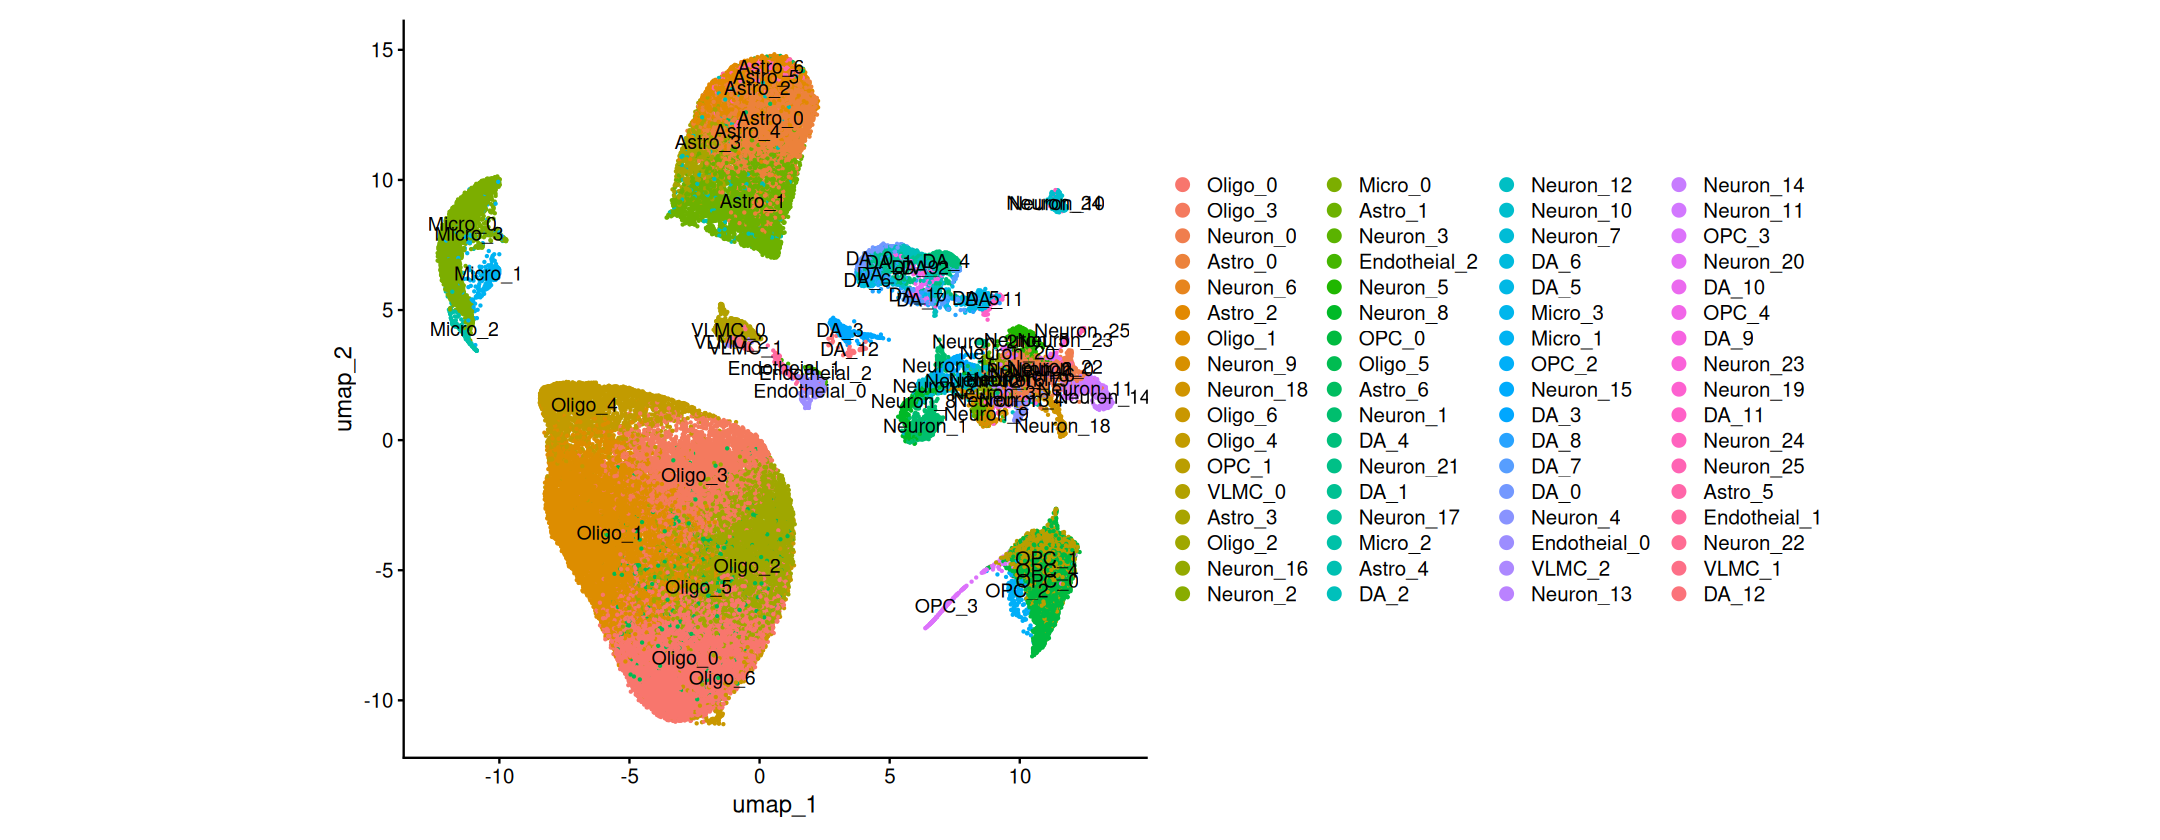

In [13]:
Idents(seurat_1) = "Subclass"
options(repr.plot.width=18, repr.plot.height=7)
DimPlot(seurat_1, reduction="umap", label=T,raster=FALSE)+coord_fixed()